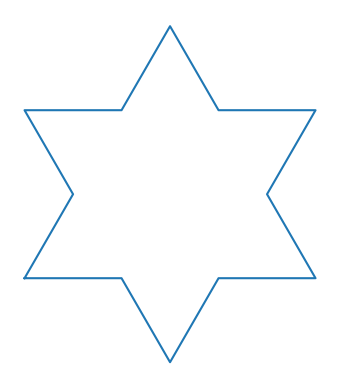

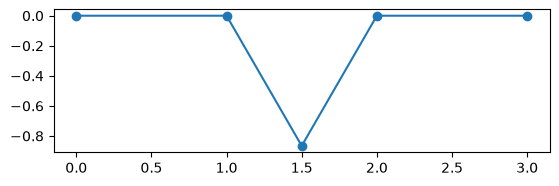

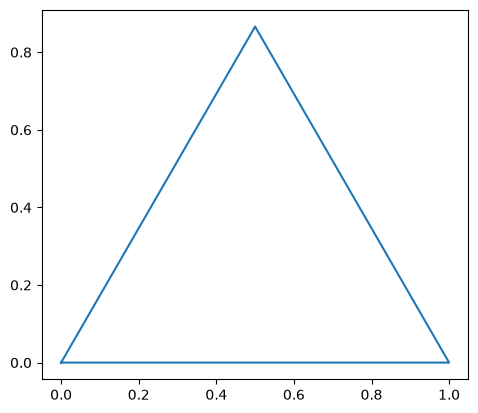

In [26]:
import torch
import matplotlib.pyplot as plt

# Equilateral triangle, centered roughly at origin
p1 = torch.tensor([0.0, 0.0])
p2 = torch.tensor([1.0, 0.0])
p3 = torch.tensor([0.5, 0.5 * (3 ** 0.5)])  # height of equilateral triangle = sqrt(3)/2

# The "polygon" is just a list of points, closed by returning to p1
points = torch.stack([p1, p2, p3, p1])

def rotate(vec, angle_deg):
    theta = torch.deg2rad(torch.tensor(angle_deg))
    cos, sin = torch.cos(theta), torch.sin(theta)
    R = torch.tensor([[cos, -sin],
                       [sin,  cos]])
    return R @ vec  # matrix-vector multiply

def koch_bump(A, B):
    p1 = A + (B - A) / 3
    p3 = A + (B - A) * 2 / 3
    peak = p1 + rotate(p3 - p1, -60)
    return torch.stack([A, p1, peak, p3, B])

##testing that the code above runs on my own, claude gave incorrect code and gave angle 
## of -60 when 60 is needed otherwise looks inverted!
A = torch.tensor([0.0, 0.0])
B = torch.tensor([3.0, 0.0])
bumped = koch_bump(A, B)

def koch_iteration(points):
    new_points = []
    for i in range(len(points) - 1):
        A = points[i]
        B = points[i + 1]
        bumped = koch_bump(A, B)
        # avoid duplicating shared points between consecutive edges
        new_points.append(bumped[:-1]) #why bumped [-1]? because bumped ends in B, and starts B to so otherwise will get duplicated
                                       #points unless slice it off here!
    new_points.append(points[-1:])  # close the shape
    return torch.cat(new_points, dim=0)
        
shape = torch.stack([p1, p2, p3, p1])  # your triangle from step 1

n_iterations = 1
for _ in range(n_iterations):
    shape = koch_iteration(shape)

plt.plot(shape[:, 0], shape[:, 1])
plt.gca().set_aspect('equal')
plt.axis('off')
plt.show()

plt.plot(bumped[:, 0], bumped[:, 1], marker='o')
plt.gca().set_aspect('equal')
plt.show()

plt.plot(points[:, 0], points[:, 1])
plt.gca().set_aspect('equal')
plt.show()